# TITLE TBD 

This notebook expands on a story whereby a user may find some object interesting, and then want to do a deep dive into what is avalible throughout the ESO and other archives using VO tools. 

The first part of this notebook covers the following: 

1) 

In this case, the user is interested in the Vera C. Rubin first look images - 
https://rubinobservatory.org/gallery/image-releases/rubin-first-look/cosmic-treasure-chest 
youtube.com/watch?v=Gitit3LwQ20&time_continue=0&source_ve_path=MjM4NTE&embeds_referring_euri=https%3A%2F%2Frubinobservatory.org%2F&embeds_referring_origin=https%3A%2F%2Frubinobservatory.org

And among the many nice objects within the feild, they find the galxy ngc 4535 (https://en.wikipedia.org/wiki/NGC_4535) interesting - known as the The Lost Galaxy...

""NGC 4535 is a barred spiral galaxy located some 54 million light years from Earth[4] in the constellation Virgo. It was discovered by German-British astronomer William Herschel on 28 December 1785.[8][9] Due to its low surface brightness, it has been called "The Lost Galaxy."[2][9]

NGC 4535 and NGC 4535A are listed together as Holm 420 in Erik Holmberg's A Study of Double and Multiple Galaxies Together with Inquiries into some General Metagalactic Problems, published in 1937.[10] However, at a distance of about 369.6 Mly (113.33 Mpc),[11] NGC 4535A is about seven times further away, so the grouping is purely an optical alignment.

NGC 4535 is a member of the Virgo Cluster of galaxies and is located 4.3° from Messier 87. The galactic plane of NGC 4535 is inclined by an angle of 43° to the line of sight from the Earth.[5] The morphological classification of NGC 4535 in the De Vaucouleurs system is SAB(s)c,[6] which indicates a bar structure across the core (SAB), no ring (s), and loosely wound spiral arms (c). The inner part of the galaxy has two spiral arms, which branch into multiple arms further away. The small[7] nucleus is of type HII, meaning the spectrum resembles that of an H II region.[6]

In 1999, the Hubble Space Telescope observed Cepheid variable stars in NGC 4535. The period-luminosity relationship for these objects yielded a distance modulus of 31.02 ± 0.26 magnitude. This corresponded to a physical distance estimate of 52.2 ± 6.2 Mly (16.0 ± 1.9) Mpc, which was consistent with distance estimates for other members of the Virgo Cluster.[12]""

They then look for other press releases and find that there is a bunch of other interesting press releases covering this object. 

HST - https://science.nasa.gov/image-detail/colours-of-the-lost-galaxy-2/
HST - https://esahubble.org/images/potw2546a/
JWST - https://esawebb.org/images/weic2403r/
ESO - https://www.eso.org/public/images/potw1312a/ 

2) They then want to check what datasets are avalible to quickly check the source (making use of aladin)
2) They then want to dig into the arXiv and try to find all papers that directly refernce this paper
3) They then want to extract some of the fundemetnal properties of the galaxy from SIMBAD and NED 

In [1]:
# Use postponed evaluation of type hints (PEP 563).
# In Python ≥3.11 this is the default behaviour, but we keep it explicit for clarity.
from __future__ import annotations

import sys
import warnings
import numpy as np
from pathlib import Path

# --- Third-party scientific libraries ---
from matplotlib import pyplot as plt
from astropy import units as u
from astropy.io import fits

# --- Astroquery (ESO) ---
import astroquery
from astroquery.eso import Eso

# --- Local helpers ---
from helpers.ipyaladin_cube import SpectralAladin
from helpers.muse_cutout import get_cutout, get_wavelengthaxis

# Suppress known LIGO/skymap warning noise
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")

# --- Environment information ---
print("Environment Information:\n")
print(f"{'Python':<12} {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

for pkg in ["numpy", "matplotlib", "astropy", "requests", "tqdm", "astroquery", "anywidget", "ipywidgets"]:
    try:
        mod = __import__(pkg)
        print(f"{pkg:<12} {mod.__version__}")
    except ImportError:
        print(f"{pkg:<12} not installed")

Environment Information:

Python       3.12.13
numpy        2.5.2
matplotlib   3.11.1
astropy      8.0.1
requests     2.34.2
tqdm         not installed
astroquery   0.4.12.dev681+gd53ceb201
anywidget    0.11.0
ipywidgets   8.1.9


In [2]:
from astropy.coordinates import SkyCoord # import the SkyCoord class from the astropy.coordinates module
import astropy.units as u # import the astropy.units module

target = "NGC4535" # set the target 
coords = SkyCoord.from_name(target) # create a SkyCoord object from the name of the source 
ra = coords.ra.deg # get the right ascension in degrees
dec = coords.dec.deg # get the declination in degrees

In [3]:
def show_aladin_linked(
    target,
    fov=0.025,
    surveys=None,
    titles=None,
    nrows=1,
    ncols=None,
):
    import math

    from ipyaladin import Aladin
    from ipywidgets import GridBox, HTML, Layout, VBox, widgets

    if not surveys:
        raise ValueError("Please provide at least one survey.")

    if titles is None:
        titles = surveys

    if len(titles) != len(surveys):
        raise ValueError("titles and surveys must have the same length.")

    if ncols is None:
        ncols = math.ceil(len(surveys) / nrows)

    if nrows * ncols < len(surveys):
        raise ValueError(
            f"The {nrows} × {ncols} grid has only {nrows * ncols} cells, "
            f"but {len(surveys)} surveys were supplied."
        )

    cosmetic_options = {
        "show_projection_control": False,
        "show_fullscreen_control": False,
        "show_zoom_control": False,
        "show_share_control": False,
        "show_simbad_pointer_control": False,
        "show_coo_grid_control": False,
        "show_settings_control": False,
        "show_context_menu": False,
        "reticle": False,
    }

    viewers = [
        Aladin(
            layout=Layout(width="100%"),
            target=target,
            survey=survey,
            fov=fov,
            **cosmetic_options,
        )
        for survey in surveys
    ]

    # Synchronize every viewer with the first one.
    for viewer in viewers[1:]:
        widgets.jslink((viewers[0], "_target"), (viewer, "_target"))
        widgets.jslink((viewers[0], "_fov"), (viewer, "_fov"))

    panels = [
        VBox(
            [
                HTML(
                    value=(
                        "<div style='text-align:center; font-weight:bold; "
                        "margin-bottom:4px;'>"
                        f"{title}</div>"
                    )
                ),
                viewer,
            ],
            layout=Layout(width="100%"),
        )
        for title, viewer in zip(titles, viewers)
    ]

    grid_layout = Layout(
        display="grid",
        grid_template_columns=f"repeat({ncols}, minmax(0, 1fr))",
        grid_template_rows=f"repeat({nrows}, auto)",
        grid_gap="8px",
        width="100%",
    )

    return GridBox(children=panels, layout=grid_layout)

surveys = [
    "CDS/P/Rubin/FirstLook",
    "P/DSS2/color",
    "P/SDSS9/color-alt",
    "P/PanSTARRS/DR1/color-i-r-g",
    "P/PanSTARRS/DR1/color-z-zg-g",
    "CDS/P/ESO/EPO",
    "CDS/P/DESI-Legacy-Surveys/DR10/color",
    "CDS/P/JWST/EPO",
        ]


titles = [
    "Rubin First Look",
    "DSS2",
    "SDSS DR9",
    "Pan-STARRS DR1 (i/r/g)",
    "Pan-STARRS DR1 (z/zg/g)",
    "ESO Public Images",
    "DESI Legacy Surveys DR10",
    "JWST Public Images",
]

show_aladin_linked(target, 
                    fov=1, 
                    surveys=surveys, 
                    titles=titles,
                    nrows=2,
                    ncols=4
)

GridBox(children=(VBox(children=(HTML(value="<div style='text-align:center; font-weight:bold; margin-bottom:4p…

In [4]:
# Query SIMBAD and NED for useful properties of the target galaxy.
from astroquery.simbad import Simbad
from astroquery.ipac.ned import Ned

simbad = Simbad()
simbad.add_votable_fields("oid", "otype", "morphtype", "rvz_redshift", "rvz_radvel", "dim")
simbad_result = simbad.query_object(target)

simbad_columns = [
    "oid", "main_id", "ra", "dec", "otype", "morph_type",
    "rvz_redshift", "rvz_radvel", "galdim_majaxis", "galdim_minaxis",
]
print("SIMBAD properties:")
simbad_result[[column for column in simbad_columns if column in simbad_result.colnames]].pprint_all()

ned_result = Ned.query_object(target)
ned_columns = [
    "Object Name", "RA", "DEC", "Type", "Velocity", "Redshift",
    "Magnitude and Filter",
]
print("\nNED properties:")
ned_result[[column for column in ned_columns if column in ned_result.colnames]].pprint_all()

velo = simbad_result["rvz_radvel"].quantity[0]

SIMBAD properties:
  oid    main_id         ra            dec      otype morph_type     rvz_redshift     rvz_radvel galdim_majaxis galdim_minaxis
                        deg            deg                                              km / s       arcmin         arcmin    
------- --------- --------------- ------------- ----- ---------- -------------------- ---------- -------------- --------------
1963370 NGC  4535 188.58476813196 8.19775235781   H2G        SAB 0.006569441507001672     1963.0        6.40866        4.97632

NED properties:
Object Name     RA        DEC     Type  Velocity   Redshift  Magnitude and Filter
             degrees    degrees          km / s                                  
----------- ---------- ---------- ---- ---------- ---------- --------------------
   NGC 4535  188.58458    8.19792    G     1964.0   0.006551                10.59


NASA ADS papers mentioning NGC4535:

2026: Mid-infrared Colors Vary with Galactic Environment: Contrasting Star-forming Disks, Young Centers, and Quiescent Star-formation Deserts
  Pathak, Debosmita, Sandstrom, Karin M., Leroy, Adam K., et al.
  Bibcode: 2026ApJ..1008...35P | Citations: 0

2026: A Virgo Environmental Survey Tracing Ionised Gas Emission (VESTIGE): XXI. Statistical properties of individual H II regions in perturbed galaxies
  Boselli, A., Fossati, M., Roehlly, Y., et al.
  Bibcode: 2026A&A...712A..46B | Citations: 1

2026: Uncovering the multi-scale structure of dust distribution in nearby galaxies
  Tanchon, E., Boquien, M., Chastenet, J., et al.
  Bibcode: 2026A&A...712A..14T | Citations: 0

2026: The PHANGS-Hα survey: Ground-based narrowband imaging of nearby star-forming galaxies
  Razza, Alessandro, Blanc, Guillermo A., Groves, Brent, et al.
  Bibcode: 2026A&A...710A.412R | Citations: 0

2026: MAUVE─MUSE: Ionization and Kinematic Signatures of Environmental Effects 

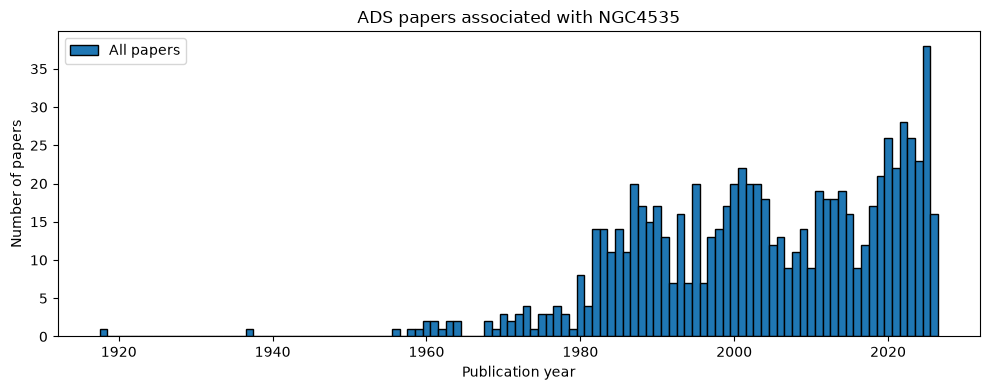

In [5]:
# Search NASA ADS for papers that mention the target in the abstract, title, or keywords.
# Make sure you get an API token first from https://ui.adsabs.harvard.edu/user/settings/token and store it in the ADS_DEV_KEY environment variable.
from astroquery.nasa_ads import ADS

# ADS reads your API token from ADS_DEV_KEY or ~/.ads/dev_key.
# These catalogue identifiers reproduce the resolved-object search used by the ADS interface.
ads_target = target
ads_simbad_id = str(simbad_result["oid"][0])
ads_ned_id = str(ned_result["Object Name"][0]).replace(" ", "_")
ads_query = (
    f'((=abs:"{ads_target}" OR simbid:"{ads_simbad_id}" OR '
    f'nedid:"{ads_ned_id}") database:astronomy)'
)
ADS.NROWS = 1000
papers = ADS.query_simple(ads_query)

print(f"NASA ADS papers mentioning {ads_target}:\n")
for paper in papers[:10]:
    title = paper["title"][0] if len(paper["title"]) else "Untitled"
    authors = ", ".join(paper["author"][:3])
    if len(paper["author"]) > 3:
        authors += ", et al."
    year = str(paper["pubdate"])[:4]
    print(f"{year}: {title}")
    print(f"  {authors}")
    print(f"  Bibcode: {paper['bibcode']} | Citations: {paper['citation_count']}\n")

def plot_publication_years(papers, ads_target, fig=None, ax=None, color="C0", label="All papers"):

    # Plot the number of returned papers published in each year.
    publication_years = np.array([int(str(pubdate)[:4]) for pubdate in papers["pubdate"]])
    year_bins = np.arange(publication_years.min() - 0.5, publication_years.max() + 1.5, 1)

    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(publication_years, bins=year_bins, color=color, edgecolor="black", label=label)
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Number of papers")
    ax.set_title(f"ADS papers associated with {ads_target}")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig, ax

fig, ax = plot_publication_years(papers, ads_target)

PART II

At this point, you may want to dig into the data more, and from the ADS search above 

NASA ADS papers associated with NGC4535 and mentioning PHANGS: 115

2026: Mid-infrared Colors Vary with Galactic Environment: Contrasting Star-forming Disks, Young Centers, and Quiescent Star-formation Deserts
  Pathak, Debosmita, Sandstrom, Karin M., Leroy, Adam K., et al.
  Bibcode: 2026ApJ..1008...35P | Citations: 0

2026: A Virgo Environmental Survey Tracing Ionised Gas Emission (VESTIGE): XXI. Statistical properties of individual H II regions in perturbed galaxies
  Boselli, A., Fossati, M., Roehlly, Y., et al.
  Bibcode: 2026A&A...712A..46B | Citations: 1

2026: Uncovering the multi-scale structure of dust distribution in nearby galaxies
  Tanchon, E., Boquien, M., Chastenet, J., et al.
  Bibcode: 2026A&A...712A..14T | Citations: 0

2026: The PHANGS-Hα survey: Ground-based narrowband imaging of nearby star-forming galaxies
  Razza, Alessandro, Blanc, Guillermo A., Groves, Brent, et al.
  Bibcode: 2026A&A...710A.412R | Citations: 0

2026: MAUVE─MUSE: Ionization and Kinematic Signa

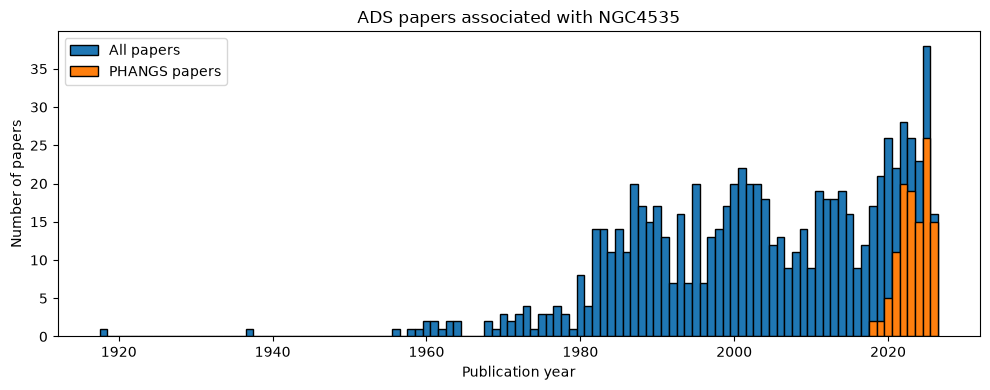

In [6]:
# Restrict the resolved NGC 4535 search to papers that also mention PHANGS.
# The full field covers title, abstract, keywords, body text, and acknowledgements.
phangs_query = f'({ads_query} AND full:"PHANGS")'

phangs_papers = ADS.query_simple(phangs_query)

print(f"NASA ADS papers associated with {ads_target} and mentioning PHANGS: {len(phangs_papers)}\n")
for paper in phangs_papers[:10]:
    title = paper["title"][0] if len(paper["title"]) else "Untitled"
    authors = ", ".join(paper["author"][:3])
    if len(paper["author"]) > 3:
        authors += ", et al."
    year = str(paper["pubdate"])[:4]
    print(f"{year}: {title}")
    print(f"  {authors}")
    print(f"  Bibcode: {paper['bibcode']} | Citations: {paper['citation_count']}\n")

fig, ax = plot_publication_years(phangs_papers, ads_target, fig, ax, color="C1", label="PHANGS papers")
fig

In [7]:
from astroquery.eso import Eso # import the ESO module from astroquery
eso = Eso() # create an instance of the ESO class 

In [8]:
surveys = eso.list_surveys() # list all collections
print(surveys) # print the list of collections

['081.C-0827', '092.A-0472', '096.B-0054', '108.2289', '109.22XS', '110.23NK', '1100.A-0528', '1101.A-0127', '193.D-0232', '195.B-0283', '196.B-0578', '196.D-0214', '197.A-0384', '198.A-0708', '60.A-9284H', '60.A-9493', 'ADHOC', 'ALCOHOLS', 'ALLSMOG', 'ALMA', 'AMAZE', 'AMBRE', 'APEX-SciOps', 'ARP_VST', 'ATLASGAL', 'BETELGEUSE-B', 'CAFFEINE', 'CRIRESplus', 'ELT-GSC', 'ENTROPY', 'ePESSTOplus', 'ERIS-NIX', 'ERIS-SPIFFIER', 'ESPRESSO', 'ESSENCE', 'FDS', 'FEROS', 'Fornax3D', 'FORS2-SPEC', 'GAIAESO', 'GCAV', 'GIRAFFE', 'GOODS_FORS2', 'GOODS_ISAAC', 'GOODS_VIMOS_IMAG', 'GOODS_VIMOS_SPEC', 'GRAVITY', 'GRB180728A_SN2018fip', 'GW170817', 'HARPS', 'HAWKI', 'HUGS', 'INSPIRE', 'INSPIRING', 'KIDS', 'KMOS', 'LEGA-C', 'LESS', 'LEWIS', 'MAGIC', 'MUSE', 'MUSE-DEEP', 'MUSE-STD', 'MW-BULGE-PSFPHOT', 'NGC1427A_MUSE-Deep', 'NGTS', 'NIRPS', 'OMEGACAM_INAF', 'PENELLOPE', 'PESSTO', 'PHANGS', 'PIONIER', 'SEDIGISM', 'SHARKS', 'SPHERE', 'SUPER', 'UltraVISTA', 'UVES', 'UVES_SQUAD', 'VANDELS', 'VEGAS', 'VEILS', 'VE

In [9]:
radius = 0.1 * u.deg # set the search radius to 0.1 degrees
table_reduced = eso.query_surveys("PHANGS",
                                cone_ra=coords.ra.value, 
                                cone_dec=coords.dec.value, 
                                cone_radius=radius.to("deg").value, 
                                ) 
# table_reduced

H-alpha rest wavelength: 656.2800 nm
Observed wavelength window: 659.4827 nm to 661.6718 nm
Requesting cutout from URL: https://dataportal.eso.org/dataPortal/soda/sync?ID=ADP.2021-07-16T10:20:56.513&BAND=6.59482674431523e-07+6.616717888754894e-07
Estimated download size: 88.8 MB
Wrote: data/NGC4535_Halpha_cutout.fits


/var/folders/3y/cmsgt3_x7x72bbs__zhy_q6h0008wr/T/ipykernel_68664/366128349.py:33: RuntimeWarning: All-NaN slice encountered
  data_cont = np.nanmedian(data, axis=0) # Median over the spectral dimension to get the (approximate) continuum map


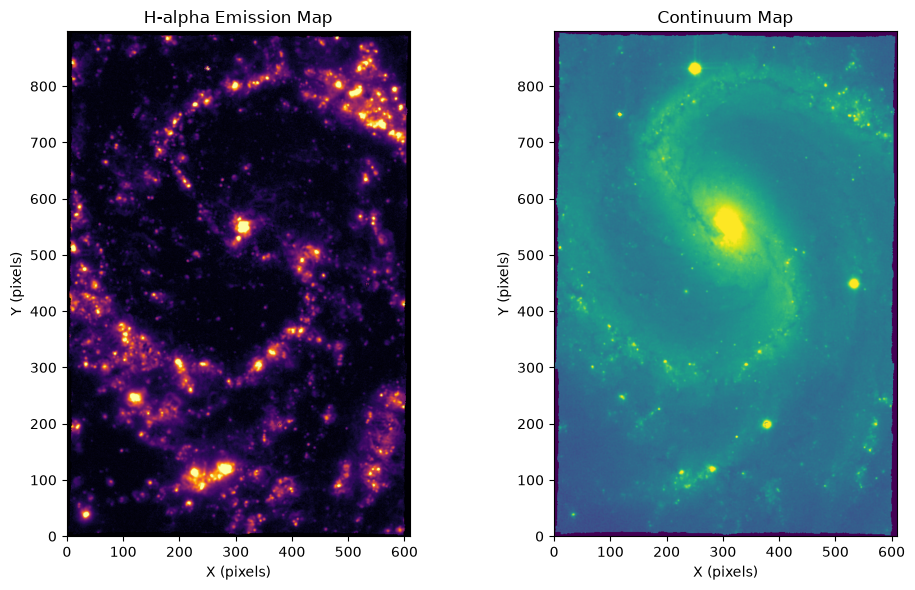

In [10]:
# Query the H-alpha rest wavelength and shift it to the velocity of the source.
from astroquery.atomic import AtomicLineList

velo_window = 500 * u.km / u.s
halpha_lines = AtomicLineList.query_object(
    wavelength_range=(656.0 * u.nm, 656.6 * u.nm),
    wavelength_type="Air",
    element_spectrum="H I",
)
halpha_rest = halpha_lines["LAMBDA AIR ANG"][0] * u.AA
doppler_halpha = u.doppler_optical(halpha_rest)
wave_min = (velo - velo_window).to(u.nm, equivalencies=doppler_halpha)
wave_max = (velo + velo_window).to(u.nm, equivalencies=doppler_halpha)

print(f"H-alpha rest wavelength: {halpha_rest.to(u.nm):.4f}")
print(f"Observed wavelength window: {wave_min:.4f} to {wave_max:.4f}")

# Get the cutout from the ESO Data Portal
outdir = "./data/"
outfile = f"{target}_Halpha_cutout.fits"
outfile = get_cutout(table_reduced["dp_id"][0], 
                    wave_min=wave_min.to(u.m).value, 
                    wave_max=wave_max.to(u.m).value, 
                    outdir=outdir, 
                    outfile=outfile, 
                    verbose=True, 
                    overwrite=True)

# Open the cutout FITS file and return the HDU list
hdul = fits.open(outfile)
data = hdul[1].data # Get image data from the second HDU
data_wave = get_wavelengthaxis(hdul) # Get the wavelength axes from the FITS file
data_cont = np.nanmedian(data, axis=0) # Median over the spectral dimension to get the (approximate) continuum map
data_line = np.nansum(data - data_cont, axis=0)  # Subtract the continuum to get the line map and sum over the spectral dimension
data_spec = np.nanmean(data - data_cont, axis=(1,2))  # Subtract the continuum to get the line map and average over the spatial dimensions


fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

map1 = np.sqrt(np.abs(data_line)) # included abs here to avoid error on sqrt of negative values
map2 = np.sqrt(np.abs(data_cont))

cmap1 = plt.cm.inferno
cmap2 = plt.cm.viridis
cmap1.set_bad(color=cmap1(0))
cmap2.set_bad(color=cmap2(0))

ax1.imshow(map1, origin='lower', cmap=cmap1, vmin=np.nanpercentile(map1, 0), vmax=np.nanpercentile(map1, 99.5))
ax2.imshow(map2, origin='lower', cmap=cmap2, vmin=0, vmax=np.nanpercentile(map2, 99.5))

ax1.set_title('H-alpha Emission Map')
ax2.set_title('Continuum Map')
ax1.set_xlabel('X (pixels)')
ax2.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax2.set_ylabel('Y (pixels)')

fig.tight_layout()

In [11]:
eso.list_catalogs()

['AMBRE_HARPS_V1',
 'AMBRE_UVES_V1',
 'AMBRE_V1',
 'AMUSED_MAIN_SOURCE_CAT_V1',
 'ATLASGAL_V1',
 'COSMOS2015_Laigle_v1_1b_latestV7_fits_V1',
 'COSMOS2020_CLASSIC_V2',
 'COSMOS2020_FARMER_V2',
 'ELT_GSC_V1',
 'EREBOS_RV_cat_fits_V1',
 'EREBOS_cat_fits_V1',
 'FDS_SourceCatalogue_V1',
 'GES_2021_VRAD',
 'GES_DR5_1_V1',
 'GNS_catalogue_V1',
 'GOODS_FORS2_V1',
 'GOODS_ISAAC_V1',
 'GOODS_VIMOS_SPEC_V1',
 'HARPS_RVCAT_V1',
 'HUGS_GOODSS_K_V1',
 'HUGS_UDS_K_V1',
 'HUGS_UDS_Y_V1',
 'INSPIRE_V1',
 'KiDS_DR3_0_ugri_src_fits_V2',
 'KiDS_DR3_1_ugri_shear_fits_V1',
 'KiDS_DR4_1_ugriZYJHKs_cat_fits',
 'KiDS_DR5_0_ugriZYJHKs_cat_fits',
 'MW_BULGE_PSFPHOT_V1',
 'NGTS_LC_V2',
 'NGTS_SOURCE_CAT_V2',
 'PESSTO_MPHOT_V3',
 'PESSTO_TRAN_CAT_V3',
 'PHANGS_DR1_NebCat',
 'UVISTA_5band_cat_dr6_rc_v1_fits_V5',
 'VANDELS_SPECTRO_V4',
 'VANDELS_spec_redshift_V3',
 'VEXAS_21_V1',
 'VEXAS_AllWISE_V1',
 'VEXAS_DESW_V2',
 'VEXAS_PSW_V2',
 'VEXAS_SMW_V2',
 'VEXAS_SPEC_GOOD_V2',
 'VEXAS_SPEC_V1',
 'VEXAS_XRAY_V1',
 'VHS_

In [12]:
table_catalog = eso.query_catalog("PHANGS_DR1_NebCat", 
                                  column_filters={"GAL_NAME": f"{target}"})
table_catalog

AV,AV_ERR,BPT_NII,BPT_OI,BPT_SII,DECJ2000,DELTA_MET_SCAL,DEPROJ_PHI,DEPROJ_R_R25,DEPROJ_R_REFF,ENVIRONMENT,EW_HA6562_FIT,EW_HA6562_FIT_ERR,EW_HA6562_RAW,EW_HA6562_RAW_ERR,EW_HB4861_FIT,EW_HB4861_FIT_ERR,EW_HB4861_RAW,EW_HB4861_RAW_ERR,FLAG_EDGE,FLAG_STAR,GAL_NAME,HA6562_FLUX,HA6562_FLUX_CORR,HA6562_FLUX_CORR_ERR,HA6562_FLUX_ERR,HA6562_LUM_CORR,HA6562_SIGMA,HA6562_SIGMA_ERR,HA6562_VEL,HA6562_VEL_ERR,HB4861_FLUX,HB4861_FLUX_CORR,HB4861_FLUX_CORR_ERR,HB4861_FLUX_ERR,LOGU,LOGU_ERR,MET_SCAL,MET_SCAL_ERR,NII6583_FLUX,NII6583_FLUX_CORR,NII6583_FLUX_CORR_ERR,NII6583_FLUX_ERR,NII6583_SIGMA,NII6583_SIGMA_ERR,NII6583_VEL,NII6583_VEL_ERR,OI6300_FLUX,OI6300_FLUX_CORR,OI6300_FLUX_CORR_ERR,OI6300_FLUX_ERR,OIII5006_FLUX,OIII5006_FLUX_CORR,OIII5006_FLUX_CORR_ERR,OIII5006_FLUX_ERR,OIII5006_SIGMA,OIII5006_SIGMA_ERR,OIII5006_VEL,OIII5006_VEL_ERR,RAJ2000,REGION_AREA,REGION_ID,SII6716_FLUX,SII6716_FLUX_CORR,SII6716_FLUX_CORR_ERR,SII6716_FLUX_ERR,SII6730_FLUX,SII6730_FLUX_CORR,SII6730_FLUX_CORR_ERR,SII6730_FLUX_ERR,SIII9068_FLUX,SIII9068_FLUX_CORR,SIII9068_FLUX_CORR_ERR,SIII9068_FLUX_ERR,SOURCE_ID
mag,mag,,,,deg,,rad,arcsec,arcsec,,angstrom,angstrom,angstrom,angstrom,angstrom,angstrom,angstrom,angstrom,,,,10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),erg / s,km / s,km / s,km / s,km / s,10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),,,,,10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),km / s,km / s,km / s,km / s,10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),km / s,km / s,km / s,km / s,deg,pix**2,,10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),10**(-20)erg.s**(-1).cm**(-2),
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object
0.49140251570676,0.17456818473637187,1.0,-1.0,0.0,8.20661639585091,--,5.064810753812125,0.143532841930427,0.4287147517046589,4.0,2.684013695111053,0.07665545585462226,0.6385358206215449,0.0672405570805793,0.9752776822415088,0.08654754904065377,-2.026809278669635,-0.1318488204994541,0.0,0.0,NGC4535,4280.823717344069,6183.670711526058,814.7730074315062,73.21942083985726,1.8400122786275426e+36,33.13898588212336,2.3470551924917697,-81.94952214775233,1.3074953238941371,1266.4433499796496,2161.9900899221116,428.75172229811596,71.99490586181938,--,--,--,--,2302.54774851026,3321.7689930641964,442.3861339307175,64.58496869093459,57.530725258734236,3.385728096903189,-73.8242285911538,2.542663214785815,65.85209839342465,96.71425884157982,106.95737312273646,72.26939143687184,669.7094162681329,1120.0628698746657,235.02172230898177,69.10855232264677,49.139458717243336,9.626406614637116,-134.21872225520576,6.969688567386191,188.58779273817635,34.0,0.0,1093.8247820467623,1565.3161932474181,219.46055216444825,64.20705642572861,825.7160844997435,1180.6402565734643,176.3070269971994,64.83546637384319,972.4738941676496,1204.670961546

In [13]:
import pyvo

datalink_url = table_reduced[table_reduced["dataproduct_subtype"]=="catalogtile"]["access_url"][0]
table_reduced_datalink = pyvo.dal.adhoc.DatalinkResults.from_result_url(datalink_url).to_table()
mask = table_reduced_datalink["semantics"] == "#auxiliary"
filenames = eso.retrieve_data(table_reduced_datalink[mask]["access_url"][0].replace("https://dataportal.eso.org/dataPortal/file/", ""), destination="./data/")

INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 1 files ... [astroquery.eso.core]
INFO: Downloading file 1/1 https://dataportal.eso.org/dataPortal/file/ADP.2025-05-14T09:12:30.244 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]
INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2025-05-14T09:12:30.244.fits [astroquery.eso.core]
INFO: Done! [astroquery.eso.core]


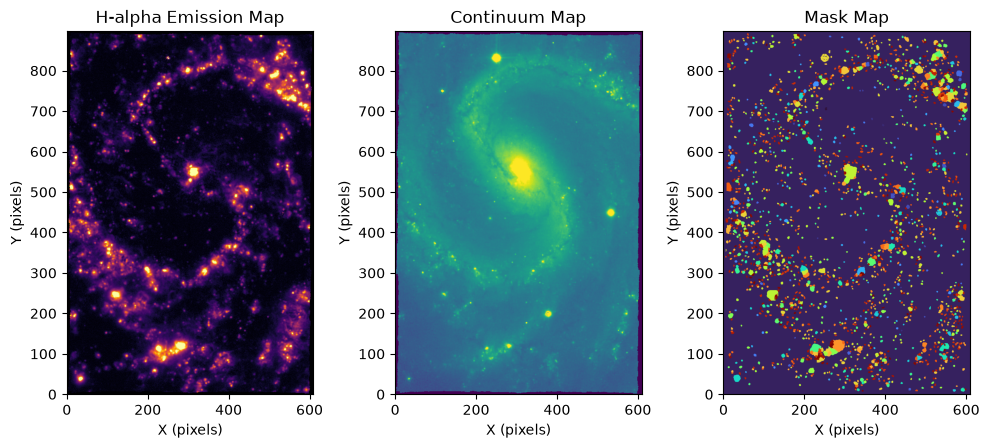

In [14]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

data_mask = fits.open(filenames)[0].data

map1 = np.sqrt(np.abs(data_line)) # included abs here to avoid error on sqrt of negative values
map2 = np.sqrt(np.abs(data_cont))
map3 = np.sqrt(np.abs(data_mask))

cmap1 = plt.cm.inferno
cmap2 = plt.cm.viridis
cmap3 = plt.cm.turbo
cmap1.set_bad(color=cmap1(0))
cmap2.set_bad(color=cmap2(0))
cmap3.set_bad(color=cmap3(0))

ax1.imshow(map1, origin='lower', cmap=cmap1, vmin=np.nanpercentile(map1, 0), vmax=np.nanpercentile(map1, 99.5))
ax2.imshow(map2, origin='lower', cmap=cmap2, vmin=0, vmax=np.nanpercentile(map2, 99.5))
ax3.imshow(map3, origin='lower', cmap=cmap3, vmin=0, vmax=np.nanpercentile(map3, 100))

ax1.set_title('H-alpha Emission Map')
ax2.set_title('Continuum Map')
ax3.set_title('Mask Map')
ax1.set_xlabel('X (pixels)')
ax2.set_xlabel('X (pixels)')
ax3.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax2.set_ylabel('Y (pixels)')
ax3.set_ylabel('Y (pixels)')

fig.tight_layout()

Requesting cutout from URL: https://dataportal.eso.org/dataPortal/soda/sync?ID=ADP.2021-07-16T10:20:56.513&CIRCLE=188.58442428879505+8.197954486426225+0.000556
data/cutout2.fits exists (set overwrite=True to replace). Skipping download.
Estimated download size: 13.6 MB
Wrote: data/cutout2.fits


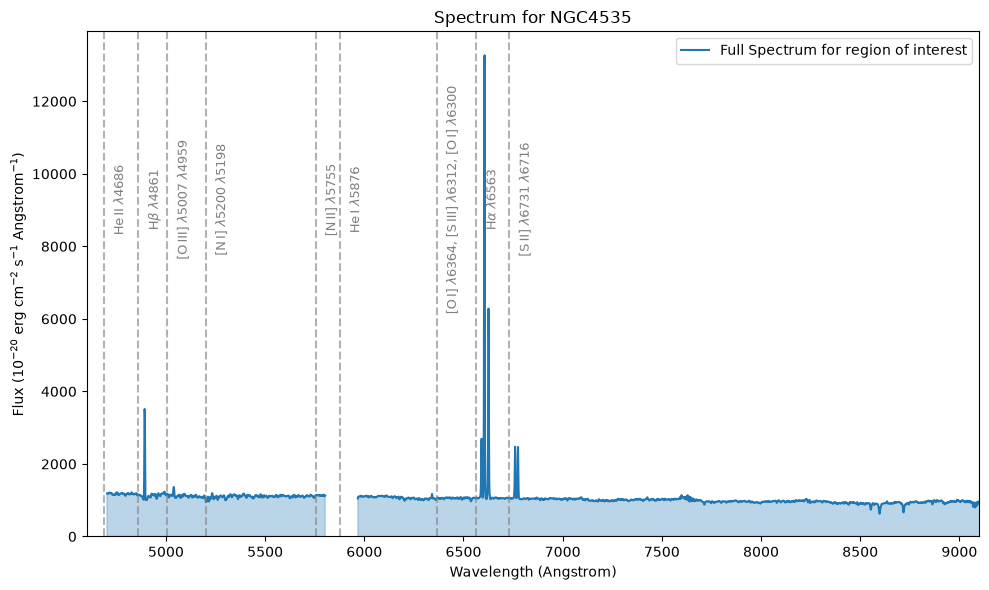

In [15]:
arg_max = np.argmax(table_catalog["HA6562_FLUX"])
ra_hiiregion, dec_hiiregion = table_catalog[arg_max]["RAJ2000", "DECJ2000"]
radius = (2 * u.arcsec).to(u.deg).value

# Get the cutout from the ESO Data Portal
# Given no constraints on wavelength, we get the full cutout
outdir = "./data/"
outfile = "cutout2.fits"
outfile = get_cutout(table_reduced["dp_id"][0], ra_hiiregion, dec_hiiregion, radius, 
                      outdir=outdir, outfile=outfile, 
                      verbose=True, overwrite=False)

# Open the cutout FITS file and return the HDU list
hdul = fits.open(outfile)

data = hdul[1].data # Get image data from the second HDU
data_wave = get_wavelengthaxis(hdul) # Get the wavelength axes from the FITS file
masked_data = np.ma.masked_invalid(data) # mask invalid values in the data (possible that some channels have all NaN values)
data_spec = masked_data.mean(axis=(1, 2)).filled(np.nan)

# Define some key emission lines in Angstrom
# Some are very close together and as such we group them... 
lines = {
    r'He II $\lambda$4686': 4686,
    r'H$\beta$ $\lambda$4861': 4861,
    r'[O III] $\lambda$5007 $\lambda$4959': 5007,
    r'[N I] $\lambda$5200 $\lambda$5198': 5200,
    r'[N II] $\lambda$5755': 5755,
    r'He I $\lambda$5876': 5876,
    r'[O I] $\lambda$6364, [S III] $\lambda$6312, [O I] $\lambda$6300': 6364,
    r'H$\alpha$ $\lambda$6563': 6563,
    r'[S II] $\lambda$6731 $\lambda$6716': 6731,
}

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(data_wave, data_spec, label='Full Spectrum for region of interest')
ax.fill_between(data_wave, 0, data_spec, where=(data_spec > 0), alpha=0.3, color='C0')

# This need updating to include the rest velocity of the source... 
# Add vertical lines and labels for key lines
for label, wave in lines.items():
    if ax.get_xlim()[0] < wave < ax.get_xlim()[1]:  # Only show if within plotting range
        ax.axvline(wave, color='gray', linestyle='--', alpha=0.6)
        ax.text(wave + 50, np.nanmax(data_spec) * 0.7, label, rotation=90,
                verticalalignment='center', fontsize=9, color='gray')

ax.set_xlabel('Wavelength (Angstrom)')
ax.set_ylabel(r'Flux (10$^{-20}$ erg cm$^{-2}$ s$^{-1}$ Angstrom$^{-1}$)')
ax.set_title(f'Spectrum for {target}')

ax.set_ylim(0, np.nanmax(data_spec) * 1.05)  # Set y-limits to avoid clipping
ax.set_xlim(4600, 9100)

ax.legend()
fig.tight_layout()

In [16]:
from astroquery.alma import Alma
from astroquery.splatalogue import Splatalogue
from helpers.alma_cutout import get_cutout

import re
from pathlib import Path
from urllib.parse import urlparse

alma = Alma()

In [17]:
line_ids = Splatalogue.get_species_ids()

# Select ground-state 12CO.
co_name = next(
    name for name in line_ids
    if name.startswith("02812 CO v = 0")
)

# Query the CO(2-1) transition.
lines = Splatalogue.query_lines(
    230 * u.GHz,
    231 * u.GHz,
    chemical_name=co_name,
    transition="2-1",
)

# Splatalogue reports orderedfreq in MHz. The same CO(2-1) transition is
# repeated for several line lists, so one row is sufficient here.
co21_rest_frequency = float(lines["orderedfreq"][0]) * u.MHz
co21_observed_frequency = velo.to(
    u.GHz,
    equivalencies=u.doppler_optical(co21_rest_frequency),
)
print(f"CO(2-1) rest frequency: {co21_rest_frequency.to(u.GHz):.6f}")
print(f"CO(2-1) observed frequency: {co21_observed_frequency:.6f}")

# A zero-radius region requires the target position itself to intersect the
# ALMA footprint. The other keywords restrict the archive query before the
# individual spectral windows are checked below.
alma = Alma()
alma_table = alma.query_region(
    coords,
    radius=0 * u.arcsec,
    public=True,
    science=True,
    band_list="6",
    spatial_resolution="0.5..1.5",
)

# Each returned row is one spectral window. Test its centre frequency and
# bandwidth directly; frequency_support is repeated across all four rows.
spw_frequency = alma_table["frequency"].quantity
half_bandwidth = alma_table["bandwidth"].quantity / 2
covers_co21 = (
    (spw_frequency - half_bandwidth <= co21_observed_frequency)
    & (co21_observed_frequency <= spw_frequency + half_bandwidth)
)
alma_table = alma_table[covers_co21]

print(f"Found {len(alma_table)} matching observation records")
print(alma_table[
    "proposal_id",
    "member_ous_uid",
    "asdm_uid",
    "target_name",
    "spatial_resolution",
    "frequency",
    "bandwidth",
])

# Expand the DataLink metadata to individual files. This only discovers URLs;
# it does not download any of the data products.
member_uids = sorted(set(alma_table["member_ous_uid"]))
data_info = alma.get_data_info(member_uids, expand_tarfiles=True)

ari_cube_urls = [
    str(url)
    for url in data_info["access_url"]
    if str(url).endswith(".cube.I.pbcor.fits")
    and ".ari_l." in str(url)
]

# Match each selected archive SPW to the nearest ARI-L science-cube centre
# encoded in the filename, while keeping member OUS and target name aligned.
cube_frequency_pattern = re.compile(r"_(\d+)MHz\.12m\.cube\.I\.pbcor\.fits$")
selected_cube_urls = []
for index, row in enumerate(alma_table):
    uid_token = str(row["member_ous_uid"]).replace("uid://", "uid___").replace("/", "_")
    target_token = str(row["target_name"])
    candidates = [
        url for url in ari_cube_urls
        if f"member.{uid_token}.ari_l.{target_token}_sci." in url
        and cube_frequency_pattern.search(url)
    ]
    spw_centre = alma_table["frequency"].quantity[index]
    selected_cube_urls.append(min(
        candidates,
        key=lambda url: abs(
            int(cube_frequency_pattern.search(url).group(1)) * u.MHz
            - spw_centre
        ),
    ))

print("Matching ARI-L primary-beam-corrected science cubes:")
for url in selected_cube_urls:
    print(url)

# Build a SODA request for a 1-arcsec-radius spatial cutout around the target.
# download=False returns the request URL without downloading the FITS cube.
ra = coords.ra.deg
dec = coords.dec.deg
velocity_half_width = 200 * u.km / u.s
doppler_co21 = u.doppler_optical(co21_rest_frequency)
wave_min = (velo - velocity_half_width).to(u.m, equivalencies=doppler_co21)
wave_max = (velo + velocity_half_width).to(u.m, equivalencies=doppler_co21)
cutout_urls = []

dp_id = Path(urlparse(selected_cube_urls[0]).path).name
outfile_alma = get_cutout(
    dp_id,
    ra=ra_hiiregion,
    dec=dec_hiiregion,
    radius=radius,
    wave_min=wave_min.value,
    wave_max=wave_max.value,
    outdir="./data/",
    outfile=f"{target}_CO21_cutout.fits",
    print_size=False,
)

CO(2-1) rest frequency: 230.538000 GHz
CO(2-1) observed frequency: 229.038289 GHz
Found 1 matching observation records
 proposal_id      member_ous_uid    ...     frequency      bandwidth 
                                    ...        GHz             Hz    
-------------- -------------------- ... ----------------- -----------
2015.1.00956.S uid://A001/X2fb/X2cd ... 229.0222643102297 937500000.0
Matching ARI-L primary-beam-corrected science cubes:
https://almascience.eso.org/dataPortal/member.uid___A001_X2fb_X2cd.ari_l.NGC_4535_sci.spw2_229022MHz.12m.cube.I.pbcor.fits
data/NGC4535_CO21_cutout.fits exists (set overwrite=True to replace). Skipping download.


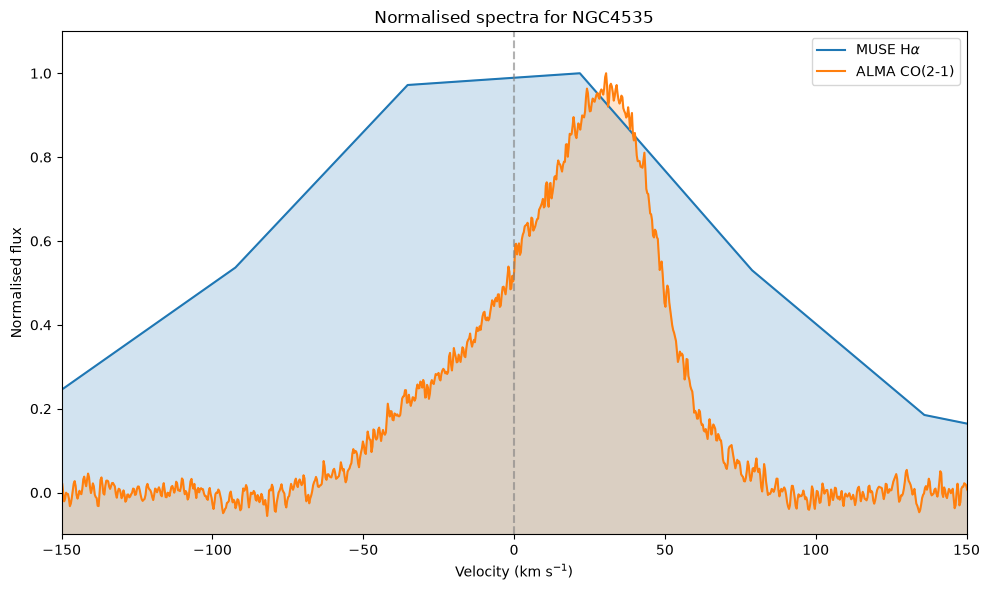

In [39]:
# Open the cutout FITS files
hdul_muse = fits.open(outfile)
hdul_alma = fits.open(outfile_alma)

# Extract the spectra by averaging over the spatial axes
muse_data = np.ma.masked_invalid(hdul_muse[1].data)
alma_data = np.ma.masked_invalid(hdul_alma[0].data)

muse_spec = muse_data.mean(axis=(1, 2)).filled(np.nan)
alma_spec = alma_data.mean(axis=(0, 2, 3)).filled(np.nan)

# Extract the spectral axes
muse_wave = get_wavelengthaxis(hdul_muse) * u.Angstrom
alma_freq = get_wavelengthaxis(hdul_alma, index=0) * u.Hz

# Rest wavelength/frequency
halpha_rest_wave = 6562.8 * u.Angstrom
co21_rest_freq = 230.538 * u.GHz

# Convert the spectral axes to velocity
muse_velocity = muse_wave.to(
    u.km / u.s,
    equivalencies=u.doppler_optical(halpha_rest_wave),
)

alma_velocity = alma_freq.to(
    u.km / u.s,
    equivalencies=u.doppler_radio(co21_rest_freq),
)

muse_velocity = muse_velocity - velo
alma_velocity = alma_velocity - velo

# Normalise each spectrum by its maximum flux
muse_spec_norm = muse_spec / np.nanmax(muse_spec)
alma_spec_norm = alma_spec / np.nanmax(alma_spec)

# Select the requested velocity range
muse_mask = (
    np.isfinite(muse_spec_norm)
    & (muse_velocity.value >= -300)
    & (muse_velocity.value <= 300)
)

alma_mask = (
    np.isfinite(alma_spec_norm)
    & (alma_velocity.value >= -300)
    & (alma_velocity.value <= 300)
)

# Plot both spectra
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    muse_velocity.value[muse_mask],
    muse_spec_norm[muse_mask],
    label=r'MUSE H$\alpha$',
    color='C0',
)

ax.fill_between(muse_velocity.value[muse_mask], -1, muse_spec_norm[muse_mask], where=(muse_spec_norm[muse_mask] > -1), alpha=0.2, color='C0')

ax.plot(
    alma_velocity.value[alma_mask],
    alma_spec_norm[alma_mask],
    label='ALMA CO(2-1)',
    color='C1',
)

ax.fill_between(alma_velocity.value[alma_mask], -1, alma_spec_norm[alma_mask], where=(alma_spec_norm[alma_mask] > -1), alpha=0.2, color='C1')

ax.axvline(0, color='gray', linestyle='--', alpha=0.6)

ax.set_ylim(-0.1, 1.1)
ax.set_xlim(-150, 150)
ax.set_xlabel(r'Velocity (km s$^{-1}$)')
ax.set_ylabel('Normalised flux')
ax.set_title(f'Normalised spectra for {target}')
ax.legend()

fig.tight_layout()
plt.show()

PART IV

In [ ]:
surveys = [
    "CDS/C/MUSE",
    "CDS/C/PHANGS-ALMA",
]

titles = [
    "MUSE",
    "PHANGS-ALMA",
]

show_aladin_linked(
    target,
    fov=0.25,
    surveys=surveys,
    titles=titles,
    nrows=2,
    ncols=1,
)